# 第5课 · 给每个频率发一张身份证——复数（complex number）的模与相位（phase），FFT 的母语

**学习目标**
1. 理解复数 `a+bj` 的直角坐标 $(a,b)$ 与极坐标 $(r, \theta)$ 表示（英文术语见下表）
2. 实现 `magnitude_phase(z)` 返回 `(模（magnitude，r）, 相位（phase，φ）)` 元组
3. 理解 FFT 输出为什么是复数：模 = 该频率（frequency）有多响，相位 = 时间对齐
4. 为 L06 欧拉公式（Euler's formula） `e^{jθ} = cos(θ) + j·sin(θ)` 打好基础

**来自 L04 的记忆**：`sinusoid` 的振幅（amplitude） A 和相位 φ，
在 FFT 输出里分别对应一个复数的**模**和**相位**。
本课让你亲手从复数中读出这两个量。

**Aurora 连接**：`magnitude_spectrogram` = 对 FFT 每个频点（frequency bin）的复数取模；
相位在以后的**波形重建**（L45）里至关重要——没有相位，往往只能还原「响不响」，很难还原「波形怎么对齐」。

← **上一课**　[L04 · 正弦波三要素](L04_trig.ipynb)

> 上节课学习了 **正弦波三要素**：频率决定音高、振幅决定响度、相位决定起点，亲手实现。  
> 本课将探讨 **复数的模与相位**：给每个频率发身份证，FFT 的母语。

## 本课剧情：给每个频率分量办一张"身份证"

FFT 分析声音时，每一个频率分量都会得到一个复数 `X[k] = a + bj`。

但"复数"到底是什么？它不是虚构的——它是一张**二维身份证**，同时记录了两件事：
- **这个频率有多响**（振幅 / 模）
- **这个频率从哪里起步**（相位）

一张身份证，两个信息，一次打包。

想象你在黑板上画一个箭头。箭头的**长度**就是振幅，箭头的**方向**就是相位。这个箭头就是复数：用极坐标写是 **$(r, \theta)$**（长度 + 方向），用直角坐标写是 `a + bj`。  
（以后会见到把方向写成 $r\cdot e^{i\theta}$ 的记号——本课先混脸熟，**L06 再拆开讲**。）

| 描述方式 | 记录什么 | 公式 |
|---|---|---|
| 直角坐标（a+bj）| 实部 a + 虚部 b | a = r·cos(θ)，b = r·sin(θ) |
| 极坐标（r, θ）| 模 r + 相位 θ | r = √(a²+b²)，θ = arctan2(b, a) |

本课你将实现 `magnitude_phase(z)`，从复数直接读出这张"身份证"的两面。

> 📌 **两个新面孔，先打招呼**：表格里的 `r·e^{iθ}` 写法，本课只需"混个脸熟"——把它读作**"长度 r、方向 θ 的箭头"**的记号即可，为什么方向要写成"e 的 iθ 次方"是下一课 L06 的正题（第 1 节里会给你一份它的"黑盒使用说明"）；`arctan2` 这个双参数的反正切也不是你高中漏学了，第 2 节动手前会专门用一小节把它讲透。

## 🤔 先想一想：不用复数，描述一个频率要几个数字？

**先别看公式，想 30 秒。** 假设你只能用实数，要完整交代"某个频率分量"，你至少得写下几个数？

- 写一个**振幅**？——不够。两个一样响的音，可能"起步时刻"不一样。
- 那再补一个**相位**。于是最少要 **两个数**：一个管多响，一个管从哪起步。
- 换个等价写法：`cos` 前面一个系数 + `sin` 前面一个系数，还是 **两个自由度**。

一个频率天生带着**两个自由度**。而一个复数 `a + bj` 恰好装两个数——一半管模（振幅）、一半管相位，严丝合缝。

> 所以复数不是数学炫技，而是一门**工程语言**：它把"描述一个频率所需的两个数"打包成一个能直接做乘法、做旋转的对象。这正是为什么 FFT 把复数当母语。

## ⚠️ 常见误解

> 不要把复数理解成"虚构 / 不存在的数字"。它其实是**"模 + 相位"两个真实自由度的打包**——一个箭头的长度和方向，两样都看得见、量得出。"虚"字只是历史遗留的坏名字。

## 1. 复数的基本操作

有没有想过：为什么数学家要发明一个"虚数单位" i（Python 用 j）？

原来，实数轴只有一个维度。乘以 -1 可以"翻转方向"，但翻转不够用——有些旋转需要**转 90°**而不是 180°。i 的定义就是"乘以 i = 逆时针旋转 90°"：

```
i² = -1（转了两次 90°= 转了 180°= 乘以 -1）
```

所以复数 `a + bj` 不是两个无关的数，而是一个**二维平面上的点**：
- 实部 a → 水平方向
- 虚部 b → 垂直方向

Python 原生支持复数；NumPy 的 `np.exp(1j * theta)` 直接给出单位圆上角度 θ 对应的点。

等一下——"乘以 i = 逆时针旋转 90°"凭什么？光宣布不算数。下面我们先用乘法分配律把它两行推出来，再用代码把旋转前后的坐标、模、相位都量给你看。（至于上一句里的 `np.exp(1j * theta)`，它也不是你"本该已经会"的东西——本节稍后有一份专门的"黑盒使用说明"。）

### 🔍 两行推演：为什么"乘以 i"就是逆时针转 90°？

你在高中学的定义是 `i² = -1`，本课却把"旋转 90°"当出发点——这两个说法其实是同一枚硬币的两面。下面不靠信仰，只靠**乘法分配律**（你初中就会的那条）把它推出来。

任取一个复数 `a + bj`，乘上 i，逐项展开：

```
(a + bj) · i = a·i + b·i² = a·i + b·(-1) = -b + a·i
```

也就是说：**点 (a, b) 被搬到了点 (-b, a)。** 这个"坐标交换 + 前面添负号"的动作，恰好就是逆时针转 90°。凭什么这么说？三个可以逐条检查的证据：

1. **长度没变**：原来的模是 √(a²+b²)，新的模是 √((-b)²+a²) = √(a²+b²)，一模一样——所以只可能是旋转或翻转，不可能是拉伸；
2. **最简单的箭头试一下**：x 轴上的箭头 (1, 0) 变成 (0, 1)，正好从"指向右"转到"指向上"，逆时针 90° 没跑；
3. **具体数字试一下**：(3, 4) 变成 (-4, 3)——在草稿纸上描这两个点，箭头正好逆时针转了直角（下面的代码格会替你量出来）。

再转一次呢？(-b, a) 按同样规则变成 (-a, -b)，也就是 (a, b) 的正对面——转两次 90° = 转 180° = 乘以 -1。**这就是 `i² = -1` 的几何出身**：它不是被规定的怪癖，而是"转两个直角等于掉头"这句大白话。

> 顺便立一块路标：本课后面还会反复用到一个更一般的事实——**乘以一个"模为 1、相位为 φ"的复数 = 把箭头逆时针转 φ**（乘以 i 只是 φ=90° 的特例）。它的两行证明要等 L06 的欧拉公式，本课先用下面的代码把它"量"出来，眼见为实。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

# 亲眼验证：乘以 i，坐标 (3,4) 是不是真的变成 (-4,3)？
z = 3 + 4j
w = z * 1j
print(f'旋转前 z   = {z}    坐标 ({z.real:.0f}, {z.imag:.0f})，模 {abs(z):.4f}，相位 {np.angle(z):.4f}')
print(f'旋转后 z*i = {w}   坐标 ({w.real:.0f}, {w.imag:.0f})，模 {abs(w):.4f}，相位 {np.angle(w):.4f}')
print(f'相位差 = {np.angle(w) - np.angle(z):.4f}，而 π/2 = {np.pi/2:.4f} —— 正好逆时针转 90°，模一点没变')
assert np.isclose(abs(w), abs(z)) and np.isclose(np.angle(w) - np.angle(z), np.pi/2)

print()
# 再看一般情形："乘以 i"不是特权，乘以任何"模 1"的复数都是纯旋转。
# 用 cos+jsin 造一个"模 1、方向 30°"的复数（这个写法下一节会正式介绍）：
rot30 = np.cos(np.pi/6) + 1j * np.sin(np.pi/6)
w30 = z * rot30
print(f'z 乘以"30°方向的单位复数"后：模 {abs(w30):.4f}（不变），'
      f'相位 {np.angle(w30):.4f} = 原相位 {np.angle(z):.4f} + π/6({np.pi/6:.4f})')
assert np.isclose(abs(w30), abs(z)) and np.isclose(np.angle(w30), np.angle(z) + np.pi/6)
print('✅ 乘以单位复数 = 只转方向、不改长度；"乘以 i"只是转角恰为 90° 的特例。')

旋转前 z   = (3+4j)    坐标 (3, 4)，模 5.0000，相位 0.9273
旋转后 z*i = (-4+3j)   坐标 (-4, 3)，模 5.0000，相位 2.4981
相位差 = 1.5708，而 π/2 = 1.5708 —— 正好逆时针转 90°，模一点没变

z 乘以"30°方向的单位复数"后：模 5.0000（不变），相位 1.4509 = 原相位 0.9273 + π/6(0.5236)
✅ 乘以单位复数 = 只转方向、不改长度；"乘以 i"只是转角恰为 90° 的特例。


### 📦 黑盒使用说明：`np.exp(1j * theta)`（本课当快捷键用，L06 拆开讲）

先说一个你可能正在犯嘀咕的事：高中里 e≈2.718，`e^x` 是"越乘越大"的指数增长——那 **e 的虚数次方**是什么鬼？为什么它不增长，反而乖乖落在单位圆上？

**这个疑问完全正当，而且本课不打算回答它**——那是下一课 L06 欧拉公式的正题。本课只跟你签一份"黑盒契约"：

> **契约**：`np.exp(1j * theta)` 是一个快捷键。你喂给它一个角度 θ，它吐给你**单位圆上角度为 θ 的那个点**，效果和 `np.cos(theta) + 1j*np.sin(theta)` **一模一样**。本课任何地方看到 `np.exp(1j*θ)`，你都可以在脑子里把它替换成 `cos(θ) + sin(θ)j`——这个写法你的高中知识完全够用。

为什么现在就让你见它？因为 FFT 的世界里人人都写 `e^{jθ}`（剧情格表格里的 `r·e^{iθ}` 也是这个记号：**长度 r、方向 θ 的箭头**），先混个脸熟，L06 揭晓原理时你会有"哦，原来是它"的快感。

下面的验证格用代码把这份契约核对一遍：两种写法逐点比较，看它们是否真的处处相等、模是否真的永远是 1。**眼见为实之后，你就可以放心把它当工具用了。**

In [3]:
import numpy as np

# 契约验证：np.exp(1j*θ) 和 np.cos(θ) + 1j*np.sin(θ) 处处相等
for theta in [0.0, np.pi/4, np.pi/2, np.pi, 5.0]:
    z_exp = np.exp(1j * theta)                 # 黑盒写法（本课的快捷键）
    z_cos = np.cos(theta) + 1j * np.sin(theta) # 高中知识就能看懂的写法
    assert np.isclose(z_exp, z_cos), '两种写法必须相等'
    print(f'θ={theta:6.3f}  np.exp(1j*θ)=({z_exp.real:+.4f}, {z_exp.imag:+.4f})   '
          f'cosθ+j·sinθ=({z_cos.real:+.4f}, {z_cos.imag:+.4f})   |z|={abs(z_exp):.4f}')

print()
print('✅ 两种写法完全一样：本课后面凡是出现 np.exp(1j*θ)，')
print('   你都可以在心里把它换成 np.cos(θ) + 1j*np.sin(θ)。')
print('   注意最右列：模永远是 1 —— 它不会"越乘越大"，只会在单位圆上绕圈。')
print('   为什么一个指数运算会乖乖绕圈？这正是 L06 欧拉公式要回答的问题。')

θ= 0.000  np.exp(1j*θ)=(+1.0000, +0.0000)   cosθ+j·sinθ=(+1.0000, +0.0000)   |z|=1.0000
θ= 0.785  np.exp(1j*θ)=(+0.7071, +0.7071)   cosθ+j·sinθ=(+0.7071, +0.7071)   |z|=1.0000
θ= 1.571  np.exp(1j*θ)=(+0.0000, +1.0000)   cosθ+j·sinθ=(+0.0000, +1.0000)   |z|=1.0000
θ= 3.142  np.exp(1j*θ)=(-1.0000, +0.0000)   cosθ+j·sinθ=(-1.0000, +0.0000)   |z|=1.0000
θ= 5.000  np.exp(1j*θ)=(+0.2837, -0.9589)   cosθ+j·sinθ=(+0.2837, -0.9589)   |z|=1.0000

✅ 两种写法完全一样：本课后面凡是出现 np.exp(1j*θ)，
   你都可以在心里把它换成 np.cos(θ) + 1j*np.sin(θ)。
   注意最右列：模永远是 1 —— 它不会"越乘越大"，只会在单位圆上绕圈。
   为什么一个指数运算会乖乖绕圈？这正是 L06 欧拉公式要回答的问题。


## 实验入口：角度、坐标和旋转

角度 θ 对应的单位复数是 `cos(θ) + sin(θ)j`：实部是水平分量，虚部是垂直分量，模恒为 1。下面遍历一圈，验证极坐标与直角坐标的互换关系。

In [4]:
import numpy as np
z = 3 + 4j
print('实部:', z.real, ' 虚部:', z.imag)
print('模 |z| =', abs(z), ' (=√(3²+4²)=5)')
print('相位(弧度) =', np.angle(z))

实部: 3.0  虚部: 4.0
模 |z| = 5.0  (=√(3²+4²)=5)
相位(弧度) = 0.9272952180016122


## 动手观察：复数就是"旋转的位置"

观察下表的 `real` 和 `imag` 列：角度每增加 π/2，坐标在单位圆（unit circle）上逆时针移一步。`magnitude` 列始终为 1，改变的只有 `phase`。

In [5]:
import numpy as np

angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
z = np.exp(1j * angles)

print('角度 =', np.round(angles, 3))
print('实部 cos =', np.round(z.real, 3))
print('虚部 sin =', np.round(z.imag, 3))
print('复数 z =', np.round(z, 3))


角度 = [0.    1.571 3.142 4.712]
实部 cos = [ 1.  0. -1. -0.]
虚部 sin = [ 0.  1.  0. -1.]
复数 z = [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]


## 代码实验：旋转一整圈

从 0 到 2π 均匀取 8 个角度，打印每个点的实部、虚部、模和相位，验证单位圆上模始终为 1、相位就是角度本身。

In [6]:
import numpy as np

for k in range(9):
    theta = 2 * np.pi * k / 8
    z = np.exp(1j * theta)
    print(f'k={k} theta={theta:.2f} -> ({z.real:+.3f}, {z.imag:+.3f})')


k=0 theta=0.00 -> (+1.000, +0.000)
k=1 theta=0.79 -> (+0.707, +0.707)
k=2 theta=1.57 -> (+0.000, +1.000)
k=3 theta=2.36 -> (-0.707, +0.707)
k=4 theta=3.14 -> (-1.000, +0.000)
k=5 theta=3.93 -> (-0.707, -0.707)
k=6 theta=4.71 -> (-0.000, -1.000)
k=7 theta=5.50 -> (+0.707, -0.707)
k=8 theta=6.28 -> (+1.000, -0.000)


## 🧭 新工具报到：`arctan2` —— 会认象限的反正切

马上要动手求相位了，但工具箱里有个新面孔必须先介绍：`np.arctan2`。**它不是你高中漏学了**——高中只教单参数的 arctan，双参数版是工程界为了修复 arctan 的一个先天缺陷而造的。

**缺陷在哪？** 想用"由斜率反查角度"的思路求相位，自然会写 `arctan(b/a)`。可是做除法 `b/a` 的那一瞬间，象限信息就被抹掉了：

- 点 `3+4j`（右上方）和点 `-3-4j`（左下方），一个指东北、一个指西南，方向**完全相反**——但 `b/a` 都等于 4/3，除法把两个负号约掉了，arctan 只能给出同一个答案；
- 更惨的是 `a = 0`（箭头竖直向上/向下）时，`b/a` 直接除以零，算都没法算。

arctan 只吃"斜率"这一个数，所以它天生只能覆盖右半圈（第一、四象限，输出范围只有 (−π/2, π/2)）。

**arctan2 的修法很直白**：别做除法了，把 b 和 a **分开**交给函数。这样 b、a 各自的正负号都还在，函数就能判断箭头指向四个象限中的哪一个，输出范围也就撑满了整整一圈：`(-π, π]`。这就是它非要两个参数不可的原因——**第二个参数不是多余的，它是被除法谋杀的象限信息的救命恩人**。

> ⚠️ **顺序警告（最容易翻车的地方）**：写法是 `np.arctan2(b, a)` = `arctan2(虚部, 实部)` = `arctan2(y, x)`——**先 y 后 x**，和平时写坐标 (x, y) 的习惯正好相反！它模仿的是分数 b/a 的"分子在前、分母在后"。更阴险的是：对 `3+4j` 这种两个分量都为正的测试值，写反成 `arctan2(3, 4)` 会得到 0.6435——也是个看起来很正常的数，只有断言会揭穿它。练习里若相位断言报错，先查参数顺序。

下面的对照实验把上面每一句话都变成可运行的证据。

In [7]:
import numpy as np

print('【第一象限：3+4j】斜率 b/a = 4/3，两个函数难分高下')
print(f'  arctan(4/3)     = {np.arctan(4/3):.4f}  ✅')
print(f'  arctan2(4, 3)   = {np.arctan2(4, 3):.4f}  ✅ 与上面一致')
print()
print('【第三象限：-3-4j】斜率 b/a = (-4)/(-3) = 4/3 —— 和上面一模一样！')
print(f'  arctan(-4/-3)   = {np.arctan(-4/-3):.4f}  ❌ 负号在除法里互相约掉，答案还是第一象限')
print(f'  arctan2(-4, -3) = {np.arctan2(-4, -3):.4f}  ✅ ≈ -2.214，第三象限（指向左下），这才对')
print()
print('【第二象限：-3+4j】')
print(f'  arctan(4/-3)    = {np.arctan(4/-3):.4f}  ❌ 给出第四象限的角，错')
print(f'  arctan2(4, -3)  = {np.arctan2(4, -3):.4f}  ✅ ≈ +2.214，第二象限（指向左上）')
print()
print('【实部为 0：纯虚数 1j】')
print('  arctan(1/0) —— 除以零，直接崩溃')
print(f'  arctan2(1, 0)   = {np.arctan2(1, 0):.4f}  ✅ = π/2，正上方，毫无压力')
print()
print('【顺序陷阱】同样是 3+4j：')
print(f'  arctan2(4, 3)   = {np.arctan2(4, 3):.4f}  ✅ 正确（虚部在前、实部在后）')
print(f'  arctan2(3, 4)   = {np.arctan2(3, 4):.4f}  ❌ 写反了！0.6435 也是个"像模像样"的数，最难查')

【第一象限：3+4j】斜率 b/a = 4/3，两个函数难分高下
  arctan(4/3)     = 0.9273  ✅
  arctan2(4, 3)   = 0.9273  ✅ 与上面一致

【第三象限：-3-4j】斜率 b/a = (-4)/(-3) = 4/3 —— 和上面一模一样！
  arctan(-4/-3)   = 0.9273  ❌ 负号在除法里互相约掉，答案还是第一象限
  arctan2(-4, -3) = -2.2143  ✅ ≈ -2.214，第三象限（指向左下），这才对

【第二象限：-3+4j】
  arctan(4/-3)    = -0.9273  ❌ 给出第四象限的角，错
  arctan2(4, -3)  = 2.2143  ✅ ≈ +2.214，第二象限（指向左上）

【实部为 0：纯虚数 1j】
  arctan(1/0) —— 除以零，直接崩溃
  arctan2(1, 0)   = 1.5708  ✅ = π/2，正上方，毫无压力

【顺序陷阱】同样是 3+4j：
  arctan2(4, 3)   = 0.9273  ✅ 正确（虚部在前、实部在后）
  arctan2(3, 4)   = 0.6435  ❌ 写反了！0.6435 也是个"像模像样"的数，最难查


## 2. ✏️ 实现 `magnitude_phase(z)` 返回 `(模, 相位)`

**推理路线**：
1. 模是复数到原点的距离：`r = √(real² + imag²)`，Python 内置 `abs(z)` 直接返回此值，对标量和 numpy 数组均适用。
2. 相位是与 x 轴正半轴的夹角：`θ = arctan2(imag, real)`，`np.angle(z)` 封装了此计算，输出范围 `(-π, π]`，单位弧度（radian）。
3. 返回元组 `(magnitude, phase)` 是因为 FFT 后处理通常同时需要两者，比分开调用两次更高效。

**参考输入输出**：`z = 3 + 4j` → 模 = 5.0，相位 ≈ 0.9273 弧度（约 53°，即 arctan(4/3)）

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `magnitude_phase` 前明确三件事：
- 输入：复数 `z`（Python 或 numpy 复数均可）
- 关键步骤：`abs(z)` 求模；`np.angle(z)` 求相位，范围 (−π, π]，单位弧度
- 返回：元组 `(magnitude, phase)`，两者均为浮点数

### 📐 手动实现规则（先自己做，再看提示）

**第一步（必做）**：仅用下列工具填写 stub：
- `z.real`，`z.imag` — 读取实部、虚部
- `np.sqrt()` — 开根号
- `np.arctan2(b, a)` — 反正切，返回 (-π, π]

**不允许** 在 stub 里直接调用 `abs(z)` 或 `np.angle(z)`（那等于零实现）。

通过断言后，在函数末尾加注释：`# 等价于: return abs(z), np.angle(z)` — 对比两种写法结果是否完全一致。

> ⚠️ **再提醒一次参数顺序**：`np.arctan2(z.imag, z.real)`——**虚部在前、实部在后**（先 y 后 x，和坐标书写习惯相反）。写反成 `arctan2(z.real, z.imag)` 对 `3+4j` 会得到 0.6435，也是个"像模像样"的数，只有断言能揪出来；断言报"相位应为 0.9273"时，第一嫌疑人就是参数顺序（详见上面"新工具报到：arctan2"一节）。

In [8]:
def magnitude_phase(z):
    # ✏️ TODO: 仅用 z.real, z.imag, np.sqrt, np.arctan2 实现（不允许直接调 abs/np.angle）
    raise NotImplementedError("请实现 magnitude_phase(z)：用 z.real, z.imag, np.sqrt, np.arctan2")


In [9]:
import numpy as np
try:
    mag, ph = magnitude_phase(3 + 4j)
    print('模 =', mag, ' 相位 =', round(ph, 4))
    assert abs(mag - 5.0) < 1e-9, f"模应为 5.0，实际得到 {mag}"
    assert abs(ph - np.arctan2(4, 3)) < 1e-9, f"相位应为 {np.arctan2(4,3):.4f}，实际得到 {ph}"
    print('✅ 通过：你能从复数读出模和相位了。')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️ 还未实现：{e}')
    print('  请回到上方 magnitude_phase 函数，用 z.real/z.imag/np.sqrt/np.arctan2 填写实现。')


⚠️ 还未实现：请实现 magnitude_phase(z)：用 z.real, z.imag, np.sqrt, np.arctan2
  请回到上方 magnitude_phase 函数，用 z.real/z.imag/np.sqrt/np.arctan2 填写实现。


**🔗 Aurora 连接**：`magnitude_spectrogram` 取的就是 FFT 复数结果的模；相位在声码器（vocoder）/重建里很关键。下一课：把复数和三角连起来——欧拉公式。

In [10]:
for k in range(8):
    theta = 2*np.pi*k/8
    z = np.exp(1j*theta)
    radius = abs(z)
    print(f'k={k} | z=({z.real:+.2f}, {z.imag:+.2f}) | 半径={radius:.2f}')
print('所有点半径都接近 1，说明它们都在单位圆上。')


k=0 | z=(+1.00, +0.00) | 半径=1.00
k=1 | z=(+0.71, +0.71) | 半径=1.00
k=2 | z=(+0.00, +1.00) | 半径=1.00
k=3 | z=(-0.71, +0.71) | 半径=1.00
k=4 | z=(-1.00, +0.00) | 半径=1.00
k=5 | z=(-0.71, -0.71) | 半径=1.00
k=6 | z=(-0.00, -1.00) | 半径=1.00
k=7 | z=(+0.71, -0.71) | 半径=1.00
所有点半径都接近 1，说明它们都在单位圆上。


## 参数实验：单位圆上 8 点的模与相位

构造 `z = np.exp(1j * np.linspace(0, 2*np.pi, 8, endpoint=False))`，打印每个点的模和相位，确认模恒为 1.0，相位以 π/4 等步长均匀分布；注意 `np.angle` 的输出范围是 (−π, π]，超过 π 的角度（5π/4、3π/2、7π/4）会折返显示为负值（−3π/4、−π/2、−π/4）。

> ⚠️ **`endpoint=False` 不能省！** 它的意思是"不含终点 2π"。因为在圆上 2π 和 0 是**同一个方向**，如果把 2π 也算进去（`np.linspace` 的默认行为），8 个点里首尾就重复了，实际只有 7 个不同方向，间隔变成 2π/7 ≈ 0.898，而不是文字里说的 π/4 ≈ 0.785。如果你照着构造式先动手、发现步长对不上——不是你敲错了，就是漏了这个参数。

再把 `3 + 4j` 换成 `3 - 4j`，观察相位从 +0.9273 变为 -0.9273：虚部取反即相位取反，模不变——验证模与相位相互独立。

In [11]:
import numpy as np

# 实验 A：单位圆上 8 点的模与相位
z8 = np.exp(1j * np.linspace(0, 2 * np.pi, 8, endpoint=False))
print('单位圆 8 点（endpoint=False，避免重复 0/2π）')
print(f'  模：{np.abs(z8).round(4)}')  # 全部应为 1.0
print(f'  相位（弧度）：{np.angle(z8).round(4)}')  # 0, π/4, ..., π，随后折返为 -3π/4, -π/2, -π/4（np.angle 范围 (-π, π]）
assert np.allclose(np.abs(z8), 1.0), '模应全部为 1.0'
print('✅ 模恒为 1，相位均匀分布')

# 实验 B：虚部取反 → 相位取反，模不变
z_pos = 3 + 4j
z_neg = 3 - 4j
print(f'\n3+4j：模={abs(z_pos):.4f}，相位={np.angle(z_pos):.4f}')
print(f'3-4j：模={abs(z_neg):.4f}，相位={np.angle(z_neg):.4f}')
assert abs(abs(z_pos) - abs(z_neg)) < 1e-9, '模应相等'
assert abs(np.angle(z_pos) + np.angle(z_neg)) < 1e-9, '相位应互为相反数'
print('✅ 虚部取反 = 相位取反，模不变')


单位圆 8 点（endpoint=False，避免重复 0/2π）
  模：[1. 1. 1. 1. 1. 1. 1. 1.]
  相位（弧度）：[ 0.      0.7854  1.5708  2.3562  3.1416 -2.3562 -1.5708 -0.7854]
✅ 模恒为 1，相位均匀分布

3+4j：模=5.0000，相位=0.9273
3-4j：模=5.0000，相位=-0.9273
✅ 虚部取反 = 相位取反，模不变


## 🖼️ 把箭头真的画出来：单位圆 8 点 + "负相位 = 顺时针量角"

课程开头就说"想象你在黑板上画一个箭头"，可到现在你看到的都是一行行数字。盯着 `k=5 -> (-0.707, -0.707)` 在脑子里描点太辛苦了——**这一格直接把黑板搬来**，matplotlib 一次画两张图：

- **左图**：上一格那 8 个点，连箭头带角度标签全画出来。你会看到 k=0..7 逆时针均匀排开，每支箭头旁标着 `np.angle` 的实际读数——注意从 k=5 开始标签突然变成负数；
- **右图**：解释这个"突然变负"。以 k=5（左下 45° 方向）为例：**同一支箭头**，逆时针量是 +5π/4（蓝色弧，绕了大半圈），顺时针量是 −3π/4（绿色弧，只绕小半圈）。`np.angle` 的规矩是"永远报绝对值不超过 π 的那条近路"，所以超过 π 的角度都折返成负值——负相位不是新方向，只是**换了个转向去量同一个方向**。

（图中标注用英文/符号是为了避免字体问题，CCW = counter-clockwise 逆时针，CW = clockwise 顺时针。）

左图：k=0..7 逆时针排开，k=5 起标签变负——那是 np.angle 改用顺时针量角了。
右图：红箭头只有一支；蓝弧（逆时针 +5π/4）和绿弧（顺时针 −3π/4）指向同一个方向。


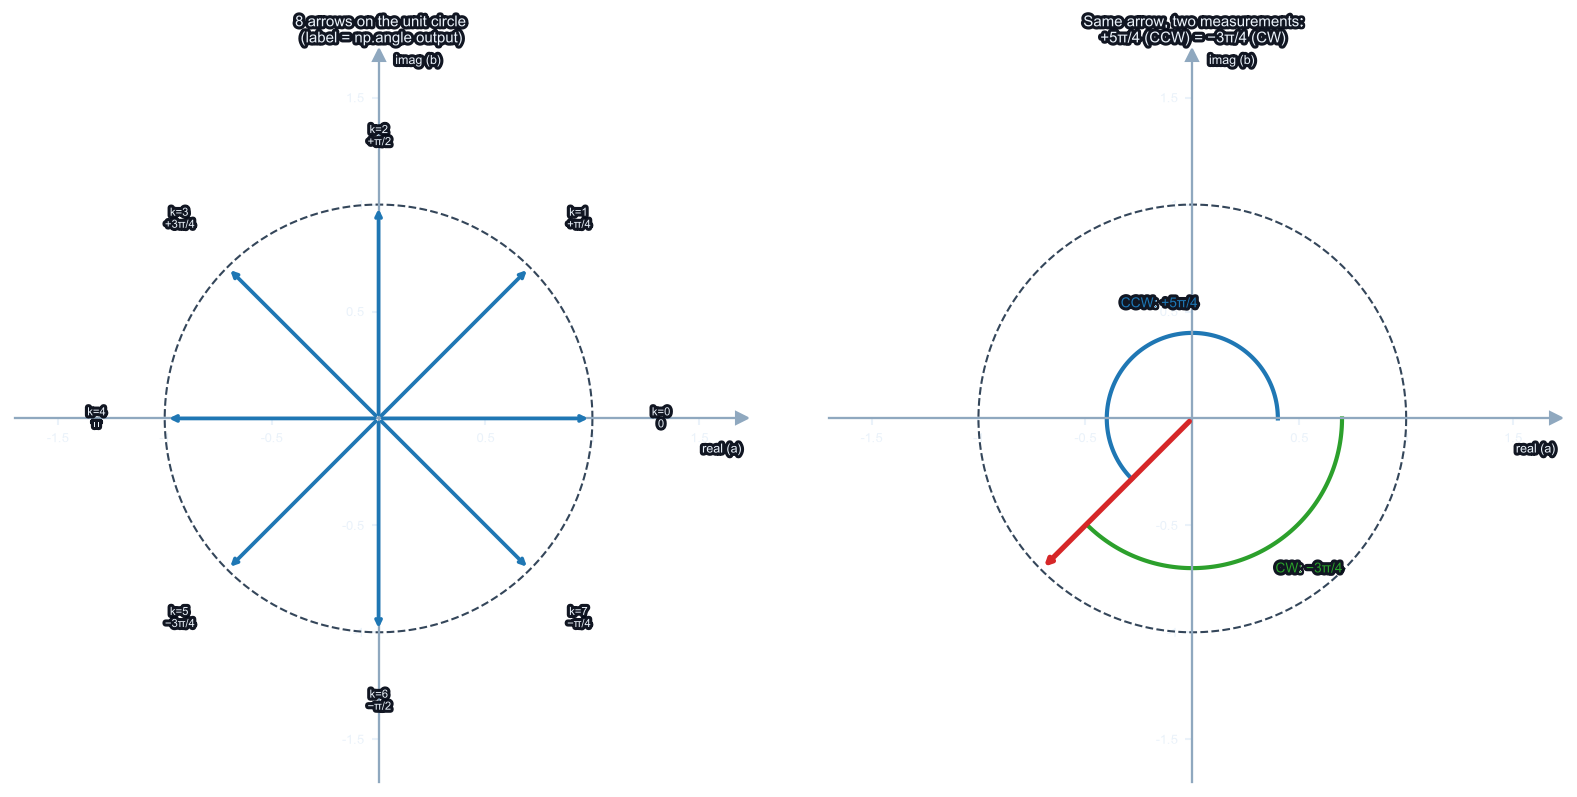

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))

# ---- 左图：单位圆上的 8 支箭头，标注 np.angle 的读数 ----
ax = axes[0]
circle = np.exp(1j * np.linspace(0, 2 * np.pi, 200))
ax.plot(circle.real, circle.imag, ls='--', lw=1, color=plt.rcParams["grid.color"])
theta8 = np.linspace(0, 2 * np.pi, 8, endpoint=False)
z8 = np.exp(1j * theta8)
labels = ['0', '+π/4', '+π/2', '+3π/4', 'π', '−3π/4', '−π/2', '−π/4']  # np.angle 的实际输出
for k, (zz, lab) in enumerate(zip(z8, labels)):
    ax.annotate('', xy=(zz.real, zz.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='C0', lw=1.8))
    ax.annotate(f'k={k}\n{lab}', xy=(zz.real * 1.32, zz.imag * 1.32),
                ha='center', va='center', fontsize=9)
ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5); ax.axvline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7); ax.set_aspect('equal')
ax.set_xlabel('real (a)'); ax.set_ylabel('imag (b)')
ax.set_title('8 arrows on the unit circle\n(label = np.angle output)')

# ---- 右图：同一支箭头的两种量法：+5π/4（逆时针）= −3π/4（顺时针）----
ax = axes[1]
ax.plot(circle.real, circle.imag, ls='--', lw=1, color=plt.rcParams["grid.color"])
zt = np.exp(1j * 5 * np.pi / 4)          # 左下方向的箭头（左图的 k=5）
ax.annotate('', xy=(zt.real, zt.imag), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C3', lw=2.5))
arc_ccw = 0.40 * np.exp(1j * np.linspace(0, 5 * np.pi / 4, 120))    # 逆时针量：+5π/4
ax.plot(arc_ccw.real, arc_ccw.imag, color='C0', lw=2)
arc_cw = 0.70 * np.exp(1j * np.linspace(0, -3 * np.pi / 4, 120))    # 顺时针量：−3π/4
ax.plot(arc_cw.real, arc_cw.imag, color='C2', lw=2)
ax.annotate('CCW: +5π/4', xy=(-0.15, 0.52), color='C0', fontsize=11, ha='center')
ax.annotate('CW: −3π/4', xy=(0.55, -0.72), color='C2', fontsize=11, ha='center')
ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5); ax.axvline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7); ax.set_aspect('equal')
ax.set_xlabel('real (a)'); ax.set_ylabel('imag (b)')
ax.set_title('Same arrow, two measurements:\n+5π/4 (CCW) = −3π/4 (CW)')

plt.tight_layout()
plt.show()
print('左图：k=0..7 逆时针排开，k=5 起标签变负——那是 np.angle 改用顺时针量角了。')
print('右图：红箭头只有一支；蓝弧（逆时针 +5π/4）和绿弧（顺时针 −3π/4）指向同一个方向。')

## FFT 输出预览：每个频点都是一个复数

不用理解推导——只看输出的数据类型和值，建立「FFT 输出 = 复数数组」的直觉。

In [13]:
import numpy as np

# 把 L04 的和弦信号做 FFT（Module 5 会从零实现；这里只看输出形状）
sr, dur = 200, 1.0
t = np.arange(round(dur * sr)) / sr
chord = (np.sin(2*np.pi*20*t) +
         np.sin(2*np.pi*32*t) +
         np.sin(2*np.pi*40*t)) / 3  # 三个频率

X = np.fft.rfft(chord)  # FFT 输出：复数数组
freqs = np.fft.rfftfreq(len(chord), 1/sr)

print(f'输入：{chord.shape}  float64')
print(f'输出：{X.shape}  {X.dtype}  ← 复数！')
print()

# 找三个峰值频率，打印对应复数
magnitudes = np.abs(X)
# 下面这行是三个操作连招，拆开看（每步都是你没见过也没关系的“查表”技巧）：
#   第 1 步 np.argsort(magnitudes)：把“下标”按模从小到大排队（返回的是下标，不是值）
#   第 2 步 [-3:]：切片，取排好队的最后 3 个——也就是模最大的 3 个下标
#   第 3 步 [::-1]：切片，步长 -1 表示倒着走一遍，把这 3 个下标翻成从大到小
top3 = np.argsort(magnitudes)[-3:][::-1]
# 等价的“新手可读版”（效果完全相同，可以自己验证）：
#   order = np.argsort(magnitudes)   # 从小到大的下标
#   top3 = list(reversed(order[len(order)-3:]))
print(f'  频率 (Hz)  |  复数 X[k]              |  模（响度）|  相位（弧度）')
print('-' * 70)
for idx in sorted(top3):
    z = X[idx]
    mag, phase = abs(z), np.angle(z)
    print(f'  {freqs[idx]:>8.1f}  |  {z.real:+.2f} + {z.imag:+.2f}j  |  {mag:.2f}        |  {phase:.3f}')

print()
print('模 ≈ 33（振幅 1/3 × 采样点数/2 = 1/3 × 100 ≈ 33）；归一化原因（Parseval 定理）将在 L40 推导，现在接受这个数字即可。')
print('相位 ≈ -π/2，因为 sin 波在 t=0 时值为 0，cos 相位领先 π/2。')
print('  ↑ 这句话里藏着一个还没交代的前提：FFT 是拿 cos 当"零相位基准"记账的——')
print('    为什么基准是 cos？要等 L06/L37 推导，和上面的"模≈33"一样先接受即可；')
print('    但"基准确实是 cos"这件事不用干等——下一格用对照实验当场演示给你看。')

输入：(200,)  float64
输出：(101,)  complex128  ← 复数！

  频率 (Hz)  |  复数 X[k]              |  模（响度）|  相位（弧度）
----------------------------------------------------------------------
      20.0  |  -0.00 + -33.33j  |  33.33        |  -1.571
      32.0  |  -0.00 + -33.33j  |  33.33        |  -1.571
      40.0  |  -0.00 + -33.33j  |  33.33        |  -1.571

模 ≈ 33（振幅 1/3 × 采样点数/2 = 1/3 × 100 ≈ 33）；归一化原因（Parseval 定理）将在 L40 推导，现在接受这个数字即可。
相位 ≈ -π/2，因为 sin 波在 t=0 时值为 0，cos 相位领先 π/2。
  ↑ 这句话里藏着一个还没交代的前提：FFT 是拿 cos 当"零相位基准"记账的——
    为什么基准是 cos？要等 L06/L37 推导，和上面的"模≈33"一样先接受即可；
    但"基准确实是 cos"这件事不用干等——下一格用对照实验当场演示给你看。


### 🔬 对照实验：FFT 的相位到底拿谁当"零点"？

上一格最后那句"相位 ≈ -π/2"可能让你心里咯噔一下：**信号明明是我用 sin 造的，凭什么相位不是 0？** 谁规定了参照物？

先把规则一句话说破：**FFT 把每个频率的成分统一写成 `A·cos(2πft + φ)` 的形式来记账**——参照物是 **cos**，不是 sin。为什么偏偏选 cos？这要等 L06 欧拉公式（cos 是 `e^{jθ}` 的实部，天生的"零相位脸"）和 L37 的 DFT 推导，现在和"模 ≈ 33"一样**先当结论接受**。

但"基准是 cos"这件事本身不用靠信——可以当场测。逻辑是这样：

1. 如果 cos 是基准，那**喂一个纯 cos 波**进去，20 Hz 频点的相位读数就该是 **0**；
2. L04 讲过 sin 落后 cos 四分之一圈（90° = π/2），所以**喂纯 sin 波**，读数就该是 **−π/2**；
3. 再加一组"抓现行"：喂 `cos(2πft + π/3)`，读数就该是 **+π/3**——FFT 读出的 φ 就是你写进 cos 括号里的那个 φ。

三个预言，下面一格一次验完。三箭齐中，"FFT 相位 = 相对 cos 的偏移"就不再是天上掉下来的了。

In [14]:
import numpy as np

sr = 200
t = np.arange(200) / sr   # 时长 1 秒 → 频率分辨率 1 Hz → 下标 20 正好是 20 Hz 频点

cases = [
    ('cos(2π·20·t)      ', np.cos(2*np.pi*20*t),           0.0),
    ('sin(2π·20·t)      ', np.sin(2*np.pi*20*t),           -np.pi/2),
    ('cos(2π·20·t + π/3)', np.cos(2*np.pi*20*t + np.pi/3), np.pi/3),
]
for name, sig, expected in cases:
    X = np.fft.rfft(sig)
    phase = np.angle(X[20])
    print(f'{name} → 20 Hz 频点的相位 = {phase:+.4f}（预期 {expected:+.4f}）')
    assert np.isclose(phase, expected, atol=1e-9)

print()
print('✅ 三个证据齐了：cos → 相位 0（它就是基准本准）；')
print('   sin 落后 cos 90° → 相位 -π/2；cos 提前 π/3 → 相位 +π/3。')
print('   结论：FFT 按 A·cos(2πft + φ) 记账，读出的相位 φ 就是"相对 cos 的偏移量"。')

cos(2π·20·t)       → 20 Hz 频点的相位 = -0.0000（预期 +0.0000）
sin(2π·20·t)       → 20 Hz 频点的相位 = -1.5708（预期 -1.5708）
cos(2π·20·t + π/3) → 20 Hz 频点的相位 = +1.0472（预期 +1.0472）

✅ 三个证据齐了：cos → 相位 0（它就是基准本准）；
   sin 落后 cos 90° → 相位 -π/2；cos 提前 π/3 → 相位 +π/3。
   结论：FFT 按 A·cos(2πft + φ) 记账，读出的相位 φ 就是"相对 cos 的偏移量"。


## 🎯 未来的回报

今天你亲手从复数里读出的**模与相位**，会在 **L06 欧拉公式 / L35、L37–L44 的 FFT 与 STFT / L70 Whisper** 一再出现——那时每个频点都是一个复数，模就是"这个频率多响"，相位就是"它怎么对齐"。今天搞懂它，后面就不必再从头猜。

## 本课收束

现在你能用自己实现的 `magnitude_phase(z)` 从任意复数读出模与相位；  
通过断言后，应能对照看出它与 `abs(z)` / `np.angle(z)` 等价（实现时禁止直接调用二者）。

**关键连接**：
- L04 的 `sinusoid(t, A=r, f=f0, phi=θ)` ↔ FFT 输出复数 `X[k]` 的 `(模=r, 相位=θ)`
- `magnitude_spectrogram = |FFT 输出|`（逐元素取模，L40 实现）
- 相位谱（phase spectrum）在波形重建（L45 STFT 逆变换）中不可或缺

**下一课 L06**：欧拉公式 `e^{jθ} = cos(θ) + j·sin(θ)`——
把今天的极坐标和上节课的正弦波直接连起来，是理解 DFT 矩阵（L37）的最短路径。

## ✏️ 白板挑战：复数手算（目标 8 分钟）

盖上屏幕，纸上作答：

**复数**：z = 3 + 4j

**问 1**：z 的模（magnitude）是多少？公式是 |z| = √(a² + b²)。

**问 2**：z 的相位（phase）是多少弧度？公式 θ = arctan2(b, a)（先手算，再运行对答案格）。

**问 3**：把 z 改写成极坐标形式 r·e^{iθ}，写出 r 和 θ 的数值。

**问 4（选做 / L06 预告，不是本课主考）**：`np.exp(1j * np.pi)` 等于多少？（Euler 公式：e^{iπ} = cos(π) + i·sin(π) = ?）

> 📌 **"手算"到什么程度算过关？** 问 2 纸上写到 **θ = arctan(4/3)，且判断出它在第一象限**，就算答对——arctan(4/3) 不是 30°/45°/60° 那种特殊角，没有计算器谁也算不出 0.9273，四位小数交给下面的对答案格。想在纸上粗验一下量级：3-4-5 直角三角形里这个角约 **53°**，53 × π/180 ≈ **0.93 弧度**，和 0.9273 对得上就说明你没算歪。问 3 的 θ 同理，写 `arctan(4/3)`（或"约 0.93"）即可。
>
> 📌 **问 4 是 L06 的预告题，不是本课的考题**：直接照括号里给的公式代入——cos(π) = −1、sin(π) = 0，加起来就是 −1——就算完成。它考的是"会抄公式代数值"，不考"理解欧拉公式为什么成立"；理解是下节课的任务，现在答不出"为什么"完全正常。

推导完成后运行下面格对答案。

In [15]:
# ✏️ 对答案格
import numpy as np

z = 3 + 4j

# 问1：模
mag_theory = 5.0  # √(9+16) = √25 = 5
mag_code = abs(z)
assert np.isclose(mag_code, mag_theory, atol=1e-10)
print(f"Q1 ✅  |3+4j| = √(9+16) = 5  代码值 {mag_code:.4f}")

# 问2：相位
ph_theory = np.arctan2(4, 3)  # ≈ 0.9273 rad
ph_code = np.angle(z)
assert np.isclose(ph_code, ph_theory, atol=1e-10)
print(f"Q2 ✅  ∠(3+4j) = arctan2(4,3) ≈ {ph_theory:.4f} rad ({np.degrees(ph_theory):.2f}°)")

# 问3：极坐标
r, theta = mag_code, ph_code
z_polar = r * np.exp(1j * theta)
assert np.isclose(z_polar.real, z.real, atol=1e-10)
assert np.isclose(z_polar.imag, z.imag, atol=1e-10)
print(f"Q3 ✅  z = {r:.1f}·e^{{i·{theta:.4f}}} = {z_polar.real:.1f} + {z_polar.imag:.1f}j (验证重合)")

# 问4：Euler 公式
z_euler = np.exp(1j * np.pi)
assert np.isclose(z_euler.real, -1.0, atol=1e-10)
assert np.isclose(z_euler.imag,  0.0, atol=1e-10)
print(f"Q4 ✅  e^{{iπ}} = cos(π) + i·sin(π) = -1 + 0j  代码值 {z_euler:.4f}")
print("\n🎉 复数白板挑战通过！模和相位就是这张频率'身份证'的两面。")

Q1 ✅  |3+4j| = √(9+16) = 5  代码值 5.0000
Q2 ✅  ∠(3+4j) = arctan2(4,3) ≈ 0.9273 rad (53.13°)
Q3 ✅  z = 5.0·e^{i·0.9273} = 3.0 + 4.0j (验证重合)
Q4 ✅  e^{iπ} = cos(π) + i·sin(π) = -1 + 0j  代码值 -1.0000+0.0000j

🎉 复数白板挑战通过！模和相位就是这张频率'身份证'的两面。


In [ ]:
# ✏️ 本课自评
l05_review = {
    "magnitude_phase_implemented": None,  # magnitude_phase 实现并通过断言？True/False
    "rectangular_polar_understood": None, # 能互相转换直角坐标↔极坐标？True/False
    # ↓ 判定标准（本课只要求"会用"，不要求"懂原理"）：能把 np.exp(1j*θ) 当作
    #   "输入角度 θ → 输出单位圆上对应点"的快捷键使用、并知道它等于 cos(θ)+sin(θ)j，
    #   就可以填 True。"为什么 e 的虚数次方会绕圈"是 L06 的内容，答不上不算没通过。
    "euler_formula_intuition":      None, # 理解 e^{iθ} 就是单位圆上旋转θ的点？True/False
    "whiteboard_passed":            None, # 白板挑战纸上推导完成？True/False（问2 写到 arctan(4/3) 即算过，见白板格说明）
}

unfilled = [k for k, v in l05_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l05_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L05 全部通关！进入 L06：欧拉公式 e^{iθ}=cosθ+isinθ')

---

→ **下一课**　[L06 · 欧拉公式 e^{iθ}=cosθ+isinθ](L06_euler.ipynb)

> 下节课将学习 **欧拉公式 e^{iθ}=cosθ+isinθ**：旋转因子是 FFT 的命根子。